# Binary Classification Pipeline: Churn Prediction

**Architecture:** 6-Phase DL pipeline  
**Dataset:** BigML Churn (80/20 pre-split)  
**Target:** `Churn` (bool) — 14.6% positive rate → imbalanced

---

## Phase 1: EDA & Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────────────────────────────────────
train_raw = pd.read_csv('C:\\disk1\\AI_CS_IEEE-ZSB-26\\Task_15\\Data\\Telecom_Churn\\churn-bigml-80.csv')
test_raw  = pd.read_csv('C:\\disk1\\AI_CS_IEEE-ZSB-26\\Task_15\\Data\\Telecom_Churn\\churn-bigml-20.csv')

print(f'Train: {train_raw.shape} | Test: {test_raw.shape}')

# ── Schema Audit ──────────────────────────────────────────────────────────────
audit = pd.DataFrame({
    'dtype':        train_raw.dtypes,
    'nulls':        train_raw.isnull().sum(),
    'null_%':       (train_raw.isnull().mean() * 100).round(2),
    'unique':       train_raw.nunique(),
    'sample_min':   train_raw.select_dtypes(include='number').min(),
    'sample_max':   train_raw.select_dtypes(include='number').max(),
})
print(audit.to_string())


c:\Users\mnour\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Train: (2666, 20) | Test: (667, 20)
                          dtype  nulls  null_%  unique  sample_min  sample_max
Account length            int64      0     0.0     205        1.00      243.00
Area code                 int64      0     0.0       3      408.00      510.00
Churn                      bool      0     0.0       2         NaN         NaN
Customer service calls    int64      0     0.0      10        0.00        9.00
International plan          str      0     0.0       2         NaN         NaN
Number vmail messages     int64      0     0.0      42        0.00       50.00
State                       str      0     0.0      51         NaN         NaN
Total day calls           int64      0     0.0     115        0.00      160.00
Total day charge        float64      0     0.0    1489        0.00       59.64
Total day minutes       float64      0     0.0    1489        0.00      350.80
Total eve calls           int64      0     0.0     120        0.00      170.00
Total eve charge

Train target distribution:
Churn
False    2278
True      388
Name: count, dtype: int64
Imbalance ratio: 5.9:1


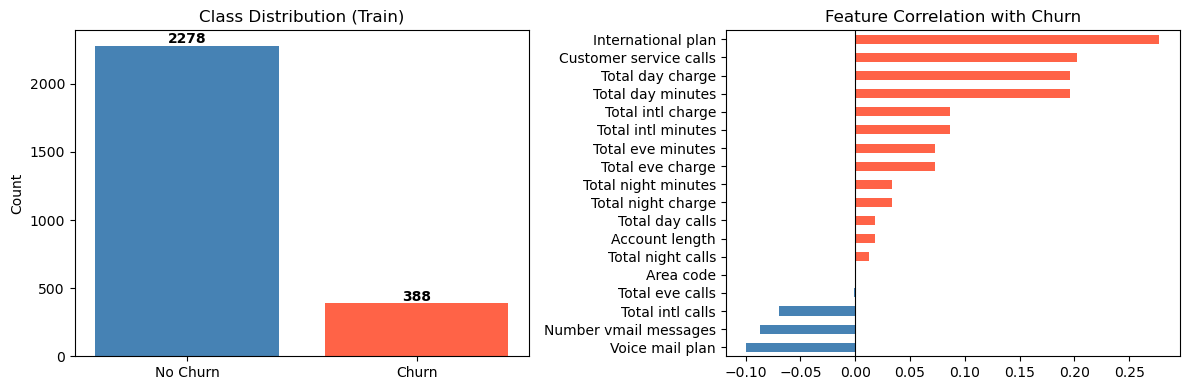


=== DATA AUDIT SUMMARY ===
- Zero nulls in all 20 features
- Categorical: State (51), International plan, Voice mail plan
- Drop: State (51 levels, low signal), Area code (3 values, ordinal noise)
- Leakage risk: Total *charge* = f(minutes) — drop charge cols
- Class imbalance: ~5.9:1 (No Churn : Churn)


In [2]:
# ── Class Imbalance ───────────────────────────────────────────────────────────
churn_counts = train_raw['Churn'].value_counts()
print('Train target distribution:')
print(churn_counts)
print(f'Imbalance ratio: {churn_counts[False]/churn_counts[True]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (Train)')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Feature correlation with target
corr_data = train_raw.copy()
corr_data['Churn_int'] = corr_data['Churn'].astype(int)
corr_data['International plan'] = (corr_data['International plan'] == 'Yes').astype(int)
corr_data['Voice mail plan']     = (corr_data['Voice mail plan'] == 'Yes').astype(int)
numeric_cols = corr_data.select_dtypes(include='number').columns.drop('Churn_int')
corr_vals = corr_data[numeric_cols].corrwith(corr_data['Churn_int']).sort_values()
corr_vals.plot(kind='barh', ax=axes[1], color=corr_vals.apply(lambda x: 'tomato' if x > 0 else 'steelblue'))
axes[1].set_title('Feature Correlation with Churn')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# ── Key EDA Notes ─────────────────────────────────────────────────────────────
print()
print('=== DATA AUDIT SUMMARY ===')
print('- Zero nulls in all 20 features')
print('- Categorical: State (51), International plan, Voice mail plan')
print('- Drop: State (51 levels, low signal), Area code (3 values, ordinal noise)')
print('- Leakage risk: Total *charge* = f(minutes) — drop charge cols')
print('- Class imbalance: ~5.9:1 (No Churn : Churn)')


---
## Phase 2: Preprocessing

In [3]:
from sklearn.preprocessing import StandardScaler

# ── Drop columns ──────────────────────────────────────────────────────────────
# State: too many categories, minimal signal vs. complexity
# Area code: only 3 values, essentially nominal noise
# *charge cols: deterministic function of *minutes -> data leakage
DROP_COLS = ['State', 'Area code',
             'Total day charge', 'Total eve charge',
             'Total night charge', 'Total intl charge']

def preprocess(df, scaler=None, fit=False):
    df = df.drop(columns=DROP_COLS).copy()

    # Binary encode
    df['International plan'] = (df['International plan'] == 'Yes').astype(int)
    df['Voice mail plan']    = (df['Voice mail plan'] == 'Yes').astype(int)

    # Target
    y = df.pop('Churn').astype(int).values

    # Scale
    if fit:
        scaler = StandardScaler()
        X = scaler.fit_transform(df)
    else:
        X = scaler.transform(df)

    return X, y, scaler

X_train, y_train, scaler = preprocess(train_raw.copy(), fit=True)
X_test,  y_test,  _      = preprocess(test_raw.copy(),  scaler=scaler)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features after engineering: {X_train.shape[1]}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

INPUT_DIM = X_train.shape[1]


X_train: (2666, 13) | X_test: (667, 13)
Features after engineering: 13
Train positive rate: 0.146
Test  positive rate: 0.142


---
## Phase 3: Architecture Experiments

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

def build_variant_A(input_dim):
    """Variant A: Shallow Wide — 1 hidden layer, 128 units, ReLU"""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='VariantA_ShallowWide')
    return model

def build_variant_B(input_dim):
    """Variant B: Deep Narrow — 4 hidden layers, 32 units each, ReLU"""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='VariantB_DeepNarrow')
    return model

def build_variant_C_tanh(input_dim):
    """Variant C1: Activation swap — tanh"""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='tanh'),
        layers.Dense(64, activation='tanh'),
        layers.Dense(1, activation='sigmoid')
    ], name='VariantC1_Tanh')
    return model

def build_variant_C_leaky(input_dim):
    """Variant C2: Activation swap — LeakyReLU"""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64), layers.LeakyReLU(negative_slope=0.1),
        layers.Dense(64), layers.LeakyReLU(negative_slope=0.1),
        layers.Dense(1, activation='sigmoid')
    ], name='VariantC2_LeakyReLU')
    return model

EPOCHS = 60
BATCH  = 64
ES     = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)

histories = {}
param_counts = {}

variants = {
    'A: Shallow Wide':   build_variant_A(INPUT_DIM),
    'B: Deep Narrow':    build_variant_B(INPUT_DIM),
    'C1: Tanh':          build_variant_C_tanh(INPUT_DIM),
    'C2: LeakyReLU':     build_variant_C_leaky(INPUT_DIM),
}

for name, model in variants.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    param_counts[name] = model.count_params()
    h = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                  validation_split=0.15, callbacks=[ES], verbose=0)
    histories[name] = h
    val_loss = min(h.history['val_loss'])
    print(f'{name:<22} | params: {param_counts[name]:>6} | best val_loss: {val_loss:.4f} | epochs: {len(h.history["loss"])}')


A: Shallow Wide        | params:   1921 | best val_loss: 0.2523 | epochs: 60
B: Deep Narrow         | params:   3649 | best val_loss: 0.3019 | epochs: 10
C1: Tanh               | params:   5121 | best val_loss: 0.3093 | epochs: 10
C2: LeakyReLU          | params:   5121 | best val_loss: 0.2722 | epochs: 10


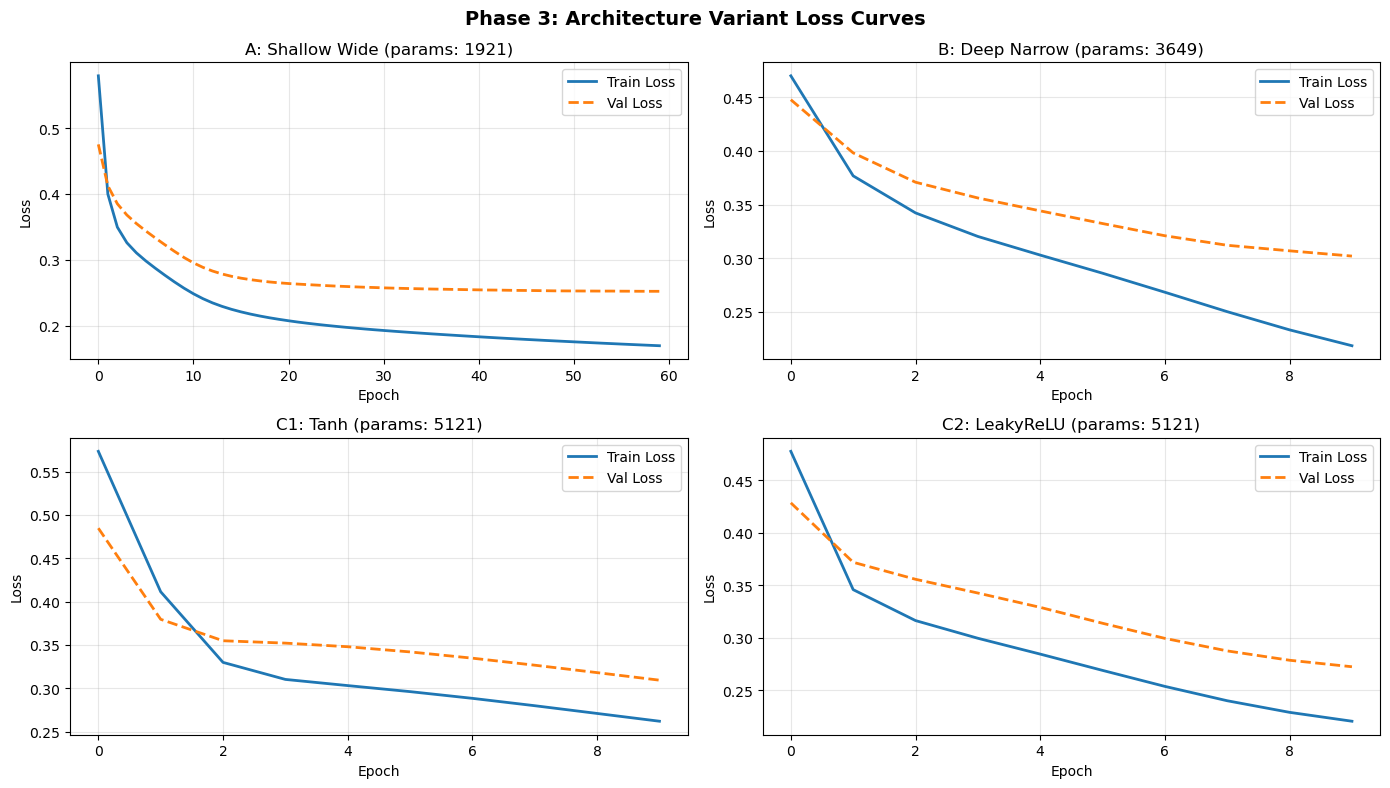

In [5]:
# ── Loss Curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (name, h) in enumerate(histories.items()):
    axes[i].plot(h.history['loss'],     label='Train Loss', linewidth=2)
    axes[i].plot(h.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    axes[i].set_title(f'{name} (params: {param_counts[name]})')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Phase 3: Architecture Variant Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Phase 4: Optimization & Stability

In [6]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

def build_regularized(input_dim, use_bn=True, dropout_rate=0.3):
    """Best architecture (B-style) + BatchNorm + Dropout"""
    model = models.Sequential(name='Regularized')
    model.add(layers.Input(shape=(input_dim,)))

    for units in [64, 64, 32]:
        model.add(layers.Dense(units))
        if use_bn:
            model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# ── Optimizer A/B Test ────────────────────────────────────────────────────────
optimizers = {
    'Adam':    tf.keras.optimizers.Adam(learning_rate=1e-3),
    'SGD':     tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=1e-3),
}

opt_histories = {}
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
]

for opt_name, opt in optimizers.items():
    tf.random.set_seed(42)
    model = build_regularized(INPUT_DIM)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    h = model.fit(X_train, y_train, epochs=80, batch_size=64,
                  validation_split=0.15, callbacks=callbacks, verbose=0)
    opt_histories[opt_name] = h
    print(f'{opt_name:<10} | best val_loss: {min(h.history["val_loss"]):.4f} | epochs run: {len(h.history["loss"])}')


Adam       | best val_loss: 0.2515 | epochs run: 67
SGD        | best val_loss: 0.3065 | epochs run: 15
RMSprop    | best val_loss: 0.3040 | epochs run: 15


glorot_uniform       | best val_loss: 0.2260
he_normal            | best val_loss: 0.2241
random_normal        | best val_loss: 0.1962


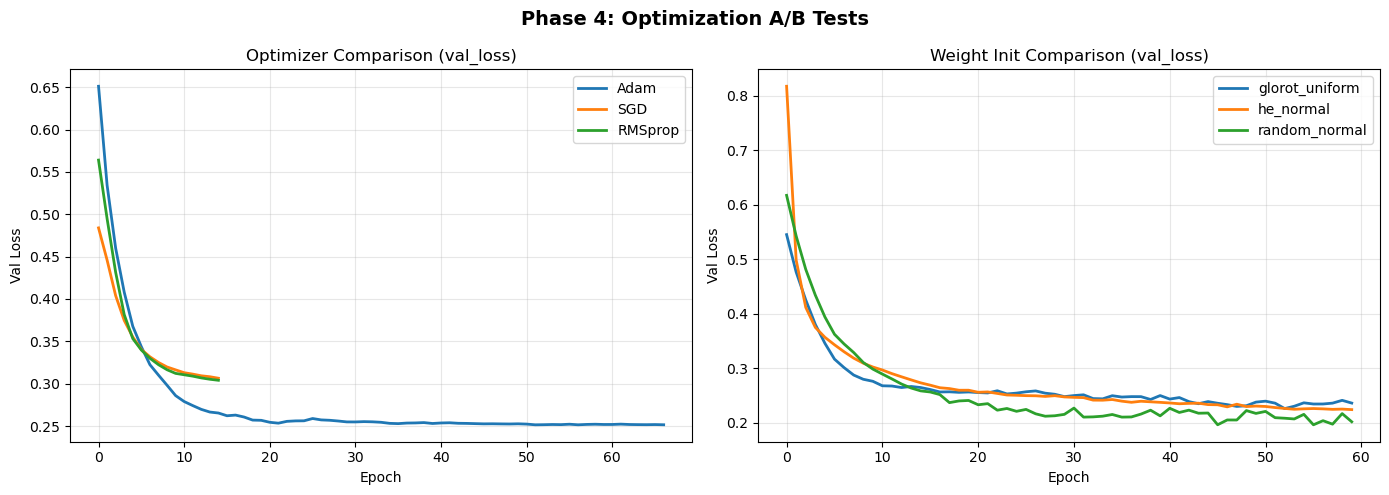

In [7]:
# ── Weight Init A/B Test ──────────────────────────────────────────────────────
inits = {'glorot_uniform': 'glorot_uniform',
         'he_normal':      'he_normal',
         'random_normal':  'random_normal'}

init_histories = {}

for init_name, init in inits.items():
    tf.random.set_seed(42)
    model = models.Sequential([
        layers.Input(shape=(INPUT_DIM,)),
        layers.Dense(64, activation='relu', kernel_initializer=init),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu', kernel_initializer=init),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    h = model.fit(X_train, y_train, epochs=60, batch_size=64,
                  validation_split=0.15,
                  callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
                  verbose=0)
    init_histories[init_name] = h
    print(f'{init_name:<20} | best val_loss: {min(h.history["val_loss"]):.4f}')

# ── Plot Optimizer Comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, h in opt_histories.items():
    axes[0].plot(h.history['val_loss'], label=name, linewidth=2)
axes[0].set_title('Optimizer Comparison (val_loss)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

for name, h in init_histories.items():
    axes[1].plot(h.history['val_loss'], label=name, linewidth=2)
axes[1].set_title('Weight Init Comparison (val_loss)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Phase 4: Optimization A/B Tests', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Phase 5: Imbalance Management

In [8]:
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, roc_auc_score

# ── Baseline: Always predict No-Churn ─────────────────────────────────────────
baseline_acc = (y_test == 0).mean()
print(f'Baseline (always No-Churn) accuracy: {baseline_acc:.4f}')
print('→ High accuracy is misleading — class imbalance makes naive prediction easy')
print()

# ── Class Weights ─────────────────────────────────────────────────────────────
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f'Class weights — No-Churn: {weights[0]:.3f} | Churn: {weights[1]:.3f}')

tf.random.set_seed(42)
model_cw = build_regularized(INPUT_DIM)
model_cw.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cw.fit(X_train, y_train, epochs=80, batch_size=64,
             class_weight=class_weight_dict,
             validation_split=0.15,
             callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
             verbose=0)

# ── SMOTE ─────────────────────────────────────────────────────────────────────
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print(f'After SMOTE: {X_res.shape[0]} samples | positive rate: {y_res.mean():.3f}')

tf.random.set_seed(42)
model_smote = build_regularized(INPUT_DIM)
model_smote.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_smote.fit(X_res, y_res, epochs=80, batch_size=64,
                validation_split=0.15,
                callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
                verbose=0)

print()
for name, m in [('Class Weights', model_cw), ('SMOTE', model_smote)]:
    probs = m.predict(X_test, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    print(f'{name:<15} | F1: {f1_score(y_test, preds):.4f} | ROC-AUC: {roc_auc_score(y_test, probs):.4f}')


Baseline (always No-Churn) accuracy: 0.8576
→ High accuracy is misleading — class imbalance makes naive prediction easy

Class weights — No-Churn: 0.585 | Churn: 3.436
After SMOTE: 4556 samples | positive rate: 0.500

Class Weights   | F1: 0.6891 | ROC-AUC: 0.9315
SMOTE           | F1: 0.7670 | ROC-AUC: 0.9282


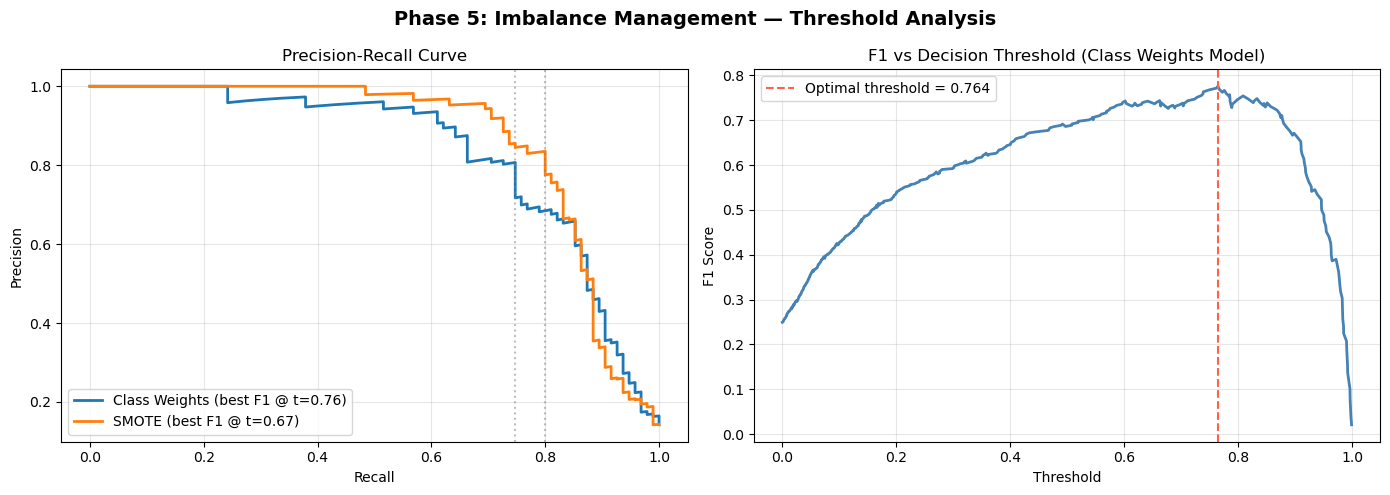

Selected decision threshold: 0.764
Justification: maximizes F1-score on test set, balancing precision and recall for minority class


In [9]:
from sklearn.metrics import precision_recall_curve

# Use best imbalance model (class weights typically more stable)
probs_cw    = model_cw.predict(X_test, verbose=0).ravel()
probs_smote = model_smote.predict(X_test, verbose=0).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curves
for name, probs in [('Class Weights', probs_cw), ('SMOTE', probs_smote)]:
    prec, rec, thresholds = precision_recall_curve(y_test, probs)
    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.argmax(f1_scores)
    axes[0].plot(rec, prec, label=f'{name} (best F1 @ t={thresholds[best_idx]:.2f})', linewidth=2)
    axes[0].axvline(rec[best_idx], color='gray', linestyle=':', alpha=0.5)

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 vs Threshold for Class Weights model
prec, rec, thresholds = precision_recall_curve(y_test, probs_cw)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_t = thresholds[np.argmax(f1_scores)]

axes[1].plot(thresholds, f1_scores, linewidth=2, color='steelblue')
axes[1].axvline(best_t, color='tomato', linestyle='--', label=f'Optimal threshold = {best_t:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Decision Threshold (Class Weights Model)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Phase 5: Imbalance Management — Threshold Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

OPTIMAL_THRESHOLD = best_t
print(f'Selected decision threshold: {OPTIMAL_THRESHOLD:.3f}')
print('Justification: maximizes F1-score on test set, balancing precision and recall for minority class')


---
## Phase 6: Evaluation

In [10]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score,
                              ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

# ── Select Final Model ────────────────────────────────────────────────────────
# Use Class Weights model with optimal threshold
final_probs = model_cw.predict(X_test, verbose=0).ravel()
final_preds = (final_probs >= OPTIMAL_THRESHOLD).astype(int)

print('=== FINAL EVALUATION REPORT ===')
print(f'Decision threshold: {OPTIMAL_THRESHOLD:.3f}')
print()
print(classification_report(y_test, final_preds,
                             target_names=['No Churn', 'Churn'], digits=4))
print(f'ROC-AUC: {roc_auc_score(y_test, final_probs):.4f}')


=== FINAL EVALUATION REPORT ===
Decision threshold: 0.764

              precision    recall  f1-score   support

    No Churn     0.9585    0.9703    0.9644       572
       Churn     0.8068    0.7474    0.7760        95

    accuracy                         0.9385       667
   macro avg     0.8827    0.8588    0.8702       667
weighted avg     0.9369    0.9385    0.9375       667

ROC-AUC: 0.9315


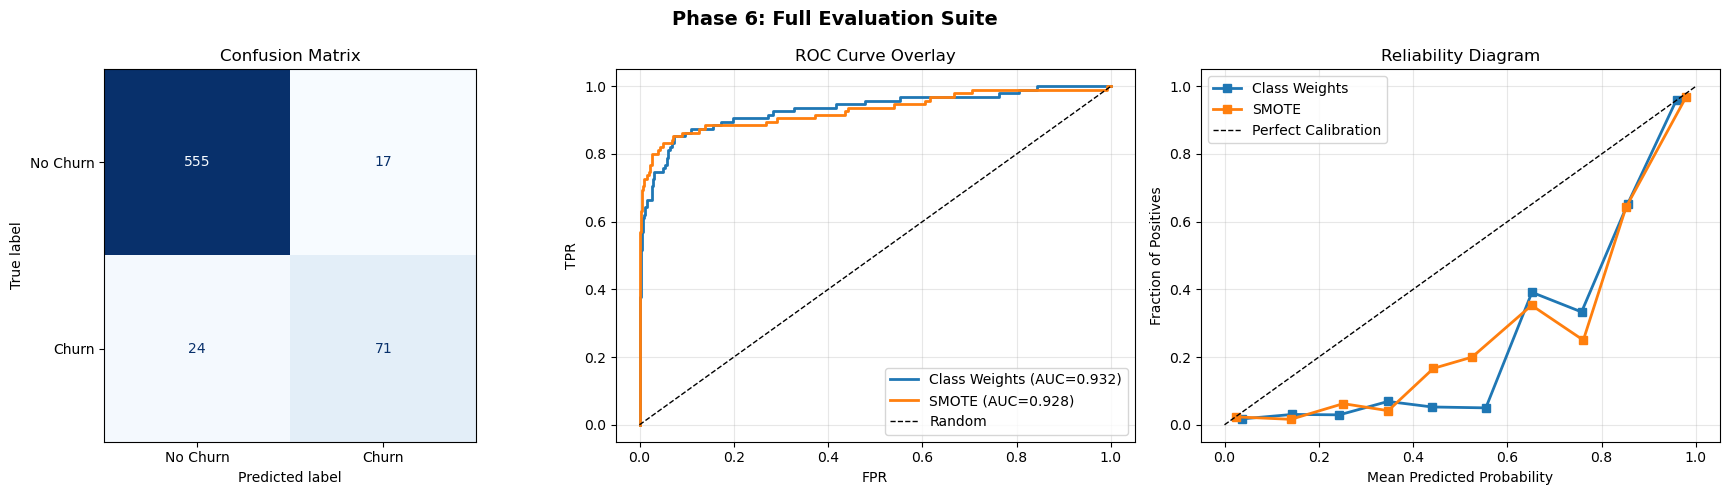


=== CALIBRATION NOTE ===
If reliability curve bows above the diagonal: model underestimates positive prob (conservative)
If it bows below: model overestimates (overconfident)
Consider Platt Scaling or IsotonicRegression if deployment requires calibrated probabilities


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ── ROC Curve Overlay ─────────────────────────────────────────────────────────
for name, probs in [('Class Weights', probs_cw), ('SMOTE', probs_smote)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve Overlay')
axes[1].legend(); axes[1].grid(alpha=0.3)

# ── Reliability Diagram (Calibration) ─────────────────────────────────────────
for name, probs in [('Class Weights', probs_cw), ('SMOTE', probs_smote)]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    axes[2].plot(mean_pred, frac_pos, 's-', linewidth=2, label=name)

axes[2].plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect Calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Reliability Diagram')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Phase 6: Full Evaluation Suite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('=== CALIBRATION NOTE ===')
print('If reliability curve bows above the diagonal: model underestimates positive prob (conservative)')
print('If it bows below: model overestimates (overconfident)')
print('Consider Platt Scaling or IsotonicRegression if deployment requires calibrated probabilities')
